# Brain Tumor Classification with Deep Learning (For Beginners! 🚀)

Welcome! In this notebook, we will build an Artificial Intelligence (AI) model capable of classifying different types of Brain Tumors from MRI images.

### What are we going to do?
1. **Load and Prepare our Data**: Computers need data organized in a specific way to learn.
2. **Preprocess & Augment**: We will resize our images and create slightly altered versions (like flipping) to help our model generalize better.
3. **Build the Brain (Model Architecture)**: We will use a highly advanced, pre-existing structure called `DenseNet121` (Transfer Learning) to help us out.
4. **Train the Model**: We'll teach the AI using our images.
5. **Evaluate & Visualize**: We'll see how smart our model actually is by showing it MRI scans it has never seen before!

Let's get started by importing the necessary Python libraries!


In [1]:
# ---------------------------------------------------------
# IMPORTING LIBRARIES
# ---------------------------------------------------------
import os                     # To interact with the operating system (e.g., reading files/folders)
import shutil                 # To copy/move files around
import random                 # To randomly shuffle our data
import numpy as np            # For numerical operations and arrays
import matplotlib.pyplot as plt # For drawing graphs and visualizing images
import seaborn as sns         # To make beautiful visualizations, like Confusion Matrices

# TensorFlow and Keras are the core libraries for building Deep Learning AI models
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

# We set fixed 'seeds' here. This ensures that every time we run this code, the random
# shuffling and calculations produce the exact same result (Reproducibility).
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print("Libraries imported successfully!")

2026-03-04 16:33:03.116928: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-04 16:33:03.117222: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-04 16:33:03.151919: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-04 16:33:04.006815: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

Libraries imported successfully!


## 1. Dataset Preparation 📁

Our data consists of MRI images divided into 44 folders representing 44 different classes (types) of conditions.

### The Problem:
Usually, when training an AI, you need **three** sets of data:
1. **Training Set (70%):** The study material. The AI uses this to learn.
2. **Validation Set (15%):** The practice tests. The AI uses this to tune itself during training.
3. **Testing Set (15%):** The final exam. Used *after* the AI finishes learning to see its true performance.

Currently, all our images are mixed together in `data/brain_tumor_data`.
In the code cell below, we create a function that automatically copies and sorts these images into three new folders (`train`, `val`, and `test`)!

In [2]:
# ---------------------------------------------------------
# PATH CONFIGURATIONS
# ---------------------------------------------------------
# Here we define the folder paths.
ORIGINAL_DATA_DIR = 'data/brain_tumor_data' # Where your images currently live
SPLIT_DATA_DIR = 'data_split/brain_tumor_data'               # The main newly created folder to hold our 3 splits

# Inside the 'data_split' directory, we will create these 3 new folders:
TRAIN_DIR = os.path.join(SPLIT_DATA_DIR, 'train')
VAL_DIR = os.path.join(SPLIT_DATA_DIR, 'val')
TEST_DIR = os.path.join(SPLIT_DATA_DIR, 'test')

In [3]:
import os

def count_images_in_splits(split_data_dir):
    # Loop through the 3 main folders (train, val, test)
    for main_split in ['train', 'val', 'test']:
        split_path = os.path.join(split_data_dir, main_split)
        
        # Check if the folder exists yet
        if not os.path.exists(split_path):
            print(f"Directory {split_path} not found.")
            continue
            
        print(f"\n--- Output for {main_split.upper()} set ---")
        
        # Look at the disease folders (glioma, meningioma, etc.)
        for disease_folder in os.listdir(split_path):
            disease_path = os.path.join(split_path, disease_folder)
            
            # Make sure it's a directory and not a random file like .DS_Store
            if os.path.isdir(disease_path):
                # Count the files inside
                image_count = len(os.listdir(disease_path))
                print(f"  > {disease_folder}: {image_count} images")

# Set this to the parent folder that contains the train/val/test folders
SPLIT_DATA_DIR = 'data_split/brain_tumor_data'
count_images_in_splits(SPLIT_DATA_DIR)


--- Output for TRAIN set ---
  > glioma: 1260 images
  > pituitary: 1260 images
  > meningioma: 1260 images
  > notumor: 1260 images

--- Output for VAL set ---
  > glioma: 270 images
  > pituitary: 270 images
  > meningioma: 270 images
  > notumor: 270 images

--- Output for TEST set ---
  > glioma: 270 images
  > pituitary: 270 images
  > meningioma: 270 images
  > notumor: 270 images


In [4]:
# ---------------------------------------------------------
# AUTOMATIC DATA SPLITTING FUNCTION
# ---------------------------------------------------------
def create_dataset_splits(source_dir, train_dir, val_dir, test_dir, split_ratios=(0.7, 0.15, 0.15)):
    '''
    This function reads images from a source directory, shuffles them, and divides them into Train, Validation, and Test directories.
    '''
    if not os.path.exists(source_dir):
        print(f"Error: Could not find the source folder: {source_dir}")
        return
        
    # Get a list of all 44 class folders inside the source directory
    classes = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]
    print(f"Discovered {len(classes)} classes of tumors.\nSplitting dataset into {split_ratios} (Train, Val, Test)...\n")
    
    # Loop through each of the 44 diseases
    for class_name in classes:
        # 1. Create sub-folders for this specific disease in train, val, and test.
        #    e.g. data_split/train/Astrocitoma_T1
        os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)
        
        # 2. Get a list of every image file for this specific disease
        class_folder_path = os.path.join(source_dir, class_name)
        images = os.listdir(class_folder_path)
        
        # 3. Shuffle the images so the AI doesn't memorize their order
        random.shuffle(images)
        
        # 4. Calculate exactly how many images correspond to 70%, 15%, and 15%
        total_images = len(images)
        train_cut = int(total_images * split_ratios[0])
        val_cut = train_cut + int(total_images * split_ratios[1])
        
        # 5. Slice the list of images based on our calculations
        train_images = images[:train_cut]
        val_images = images[train_cut:val_cut]
        test_images = images[val_cut:]
        
        # 6. Finally, loop through these sliced lists, and copy the actual .jpg/.png files over
        for img in train_images:
            shutil.copy(os.path.join(class_folder_path, img), os.path.join(train_dir, class_name, img))
        for img in val_images:
            shutil.copy(os.path.join(class_folder_path, img), os.path.join(val_dir, class_name, img))
        for img in test_images:
            shutil.copy(os.path.join(class_folder_path, img), os.path.join(test_dir, class_name, img))
            
    print("✅ Success! Images have been split into the robust 'data_split/' directory.")

# -> RUN THE SPLITTER
# It might take a minute depending on how many thousands of files there are!
create_dataset_splits(ORIGINAL_DATA_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR)

Discovered 4 classes of tumors.
Splitting dataset into (0.7, 0.15, 0.15) (Train, Val, Test)...

✅ Success! Images have been split into the robust 'data_split/' directory.


## 2. Data Preprocessing & Augmentation 🖼️

Now that our data is separated into Train, Validation, and Test folders, we can't just throw raw images into the AI. We need to **Pre-process** them.

### What must be done?
1. **Resizing:** Images come in all shapes. We must force them to all be `224x224` pixels because our AI Architecture expects uniform squares.
2. **Normalization:** Image pixels are numbered 0 to 255 (0 is black, 255 is white). Neural networks prefer numbers between 0.0 and 1.0! So, we will use DenseNet's specific `preprocess_input` function.

### Data Augmentation (Training ONLY)
To prevent our AI from "memorizing" specific training images (Overfitting), we dynamically alter the training images slightly before feeding them in. We rotate them, stretch them, and flip them! The AI sees a slightly different variation every time, making it smarter!

> We **do NOT** augment the Validation or Test Sets. We want to test the model on normal, un-altered images.

In [5]:
# We define a standard, squared target size
IMG_WIDTH, IMG_HEIGHT = 224, 224
IMG_SIZE = (IMG_WIDTH, IMG_HEIGHT)

# BATCH SIZE: How many images the AI processes at once before updating its "memory".
# 32 is standard. If your computer crashes running out of memory, lower this to 16.
BATCH_SIZE = 16

# -------------------------------------------------------------
# DEFINING THE "GENERATORS"
# -------------------------------------------------------------

# 1. Training Generator (Includes Data Augmentation!)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,               # Normalize pixel values for DenseNet
    rotation_range=15,            # Randomly rotate image laterally by up to 15 degrees
    width_shift_range=0.1,        # Shift image horizontally by 10%
    height_shift_range=0.1,       # Shift image vertically by 10%
    brightness_range=[0.9, 1.1],  # Randomly darken or lighten by 10%
    horizontal_flip=True          # Flips the MRI scan (Left becomes right)
)

# 2. Validation & Testing Generator (NO Augmentation, ONLY Normalization)
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [6]:
from IPython.display import display, HTML

# -------------------------------------------------------------
# LOADING THE IMAGES FROM FOLDERS INTO MEMORY
# -------------------------------------------------------------
print("Preparing Data Batches:\n")

# Connect the Train Generator to the 'train' folder
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'   # We use 'categorical' because we have 44 mutually-exclusive diseases
)

# Connect the Val Generator to the 'val' folder
val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False              # Do not shuffle validation, keep it consistent for plotting
)

# Connect the Test Generator to the 'test' folder
test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False              # Do not shuffle testing, so we can perfectly compare True vs Predicted Labels later
)

# Extract important variables to use later
NUM_CLASSES = train_generator.num_classes
class_names = list(train_generator.class_indices.keys())

print(f"\n ✅ We discovered {NUM_CLASSES} distinct Brain Tumor classes!")

Preparing Data Batches:

Found 5040 images belonging to 4 classes.
Found 1080 images belonging to 4 classes.
Found 1080 images belonging to 4 classes.

 ✅ We discovered 4 distinct Brain Tumor classes!


## 3. The Brain (Model Architecture) 🧠

Writing an AI from scratch to detect tumors takes millions of images and huge computation. Instead, we use **Transfer Learning**.

We load `DenseNet121`—an incredible image classification AI built by Google that has *already* learned how to "see" shapes, edges, and objects by looking at 14 million daily-life images (the ImageNet dataset).

### Creating our custom Tumor Detective:
1. Load `DenseNet121` without its "head" (its original ability to classify 1,000 random objects like dogs, cars, TVs).
2. "Freeze" the body, so we don't accidentally erase its ability to physically "see" edges and textures.
3. Add our own custom "Head" (the Dense layers) responsible for classifying the 44 specific Brain Tumors via the `Softmax` function!

Let's build it!

In [7]:
# 1. Provide the pre-trained DenseNet121 BASE
base_model = DenseNet121(
    weights='imagenet',          # Use the intelligence learned from Google's ImageNet dataset
    include_top=False,           # Remove the original "head" of the AI
    input_shape=(224, 224, 3)    # Give it our 224x224 RGB Image constraints
)

# 2. Freeze the base layers so we don't ruin what it already knows
base_model.trainable = False

# Freeze all layers except last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

# 3. Stack on our custom Brain Tumor Classification Layers!
x = base_model.output

# Reduce the overwhelming 3D geometry of the base output into a neat 1D array
x = GlobalAveragePooling2D()(x)

# Dropout turns off 30% of neurons randomly. This forces the remaining neurons to work harder!
# (It dramatically reduces 'Overfitting' - when an AI memorizes data instead of actually learning).
x = Dropout(0.5)(x)

# Finally, our "Head" logic. A Dense layer with 44 nodes (One for each disease).
# Softmax ensures that all 44 probabilities add up to 100%. "I am 80% sure this is cancer."
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

# --------------------------
# COMPILE AND BIND THE MODEL
# --------------------------
# We merge the Google Base with our Custom Head:
model = Model(inputs=base_model.input, outputs=predictions)

# Compiling configures HOW the AI learns.
model.compile(
    optimizer=Adam(learning_rate=1e-4),  # The Adam Optimizer automatically tunes the learning math formulas!
    loss='categorical_crossentropy',      # The formula to calculate exactly "how wrong" the current AI guess is
    metrics=['accuracy']                  # We want human-readable accuracy percentages
)

# Print a block showing the AI's internal physical structure
model.summary()

2026-03-04 16:33:04.915635: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 75s 3us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,041,604 (26.86 MB)

 Trainable params: 4,100 (16.02 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

## 4. Training (Teaching the AI) 🎓

Now we enter the most computationally heavy phase.

We set `EPOCHS = 30`. One "Epoch" means the AI will look at every single image in the Train set exactly one time.

### Smart Interventions (Callbacks):
To ensure perfection, we add 3 smart tools that watch the AI while it trains:
1. `EarlyStopping`: If the Validation Loss stops improving for 5 epochs... the AI has stopped learning. Auto-Stop the training to save time!
2. `ReduceLROnPlateau`: Sometimes the learning math (gradient descent) gets "stuck". This reduces the learning-rate jumps making learning more precise when stalled.
3. `ModelCheckpoint`: Behind the scenes, we automatically save the physical `.h5` model file to the hard drive on the exact epoch where it scored the best!

In [8]:
EPOCHS = 15

# Where we will save the finalized trained AI model
os.makedirs('../inference/models', exist_ok=True)
MODEL_SAVE_PATH = '../inference/models/brain_tumor_densenet121.h5'

# 1. Early Stopping Rule
early_stopping = EarlyStopping(
    monitor='val_loss',         # Watch how 'wrong' the Validation test is
    patience=5,                 # Wait 5 epochs before giving up
    restore_best_weights=True,  # Ensure our final model rolls-back to its best Epoch!
    verbose=1
)

# 2. Modify Learning Speed Rule
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,                 # If stuck, divide the learning speed (jump size) by 5.
    patience=3,                 # Do this if it gets stuck for 3 epochs
    min_lr=1e-6,                # Don't let it slow down endlessly. Bottom threshold.
    verbose=1
)

# 3. Model Saver
model_checkpoint = ModelCheckpoint(
    filepath=MODEL_SAVE_PATH,
    monitor='val_loss',
    save_best_only=True,        # ONLY Overwrite the file if THIS epoch beats the previous high-score
    verbose=1
)

print("Starting to train the AI... This will take some time! Grab a coffee ☕")

# --> TEACH THE MODEL <--
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stopping, reduce_lr, model_checkpoint]
)

print(f"\n✅ Training concluded! The best version was safely deposited at {MODEL_SAVE_PATH}")

Starting to train the AI... This will take some time! Grab a coffee ☕
Epoch 1/15
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 754ms/step - accuracy: 0.2997 - loss: 2.0069
Epoch 1: val_loss improved from None to 1.04315, saving model to ../inference/models/brain_tumor_densenet121.h5



Epoch 1: finished saving model to ../inference/models/brain_tumor_densenet121.h5
315/315 ━━━━━━━━━━━━━━━━━━━━ 299s 932ms/step - accuracy: 0.3353 - loss: 1.8049 - val_accuracy: 0.5389 - val_loss: 1.0432 - learning_rate: 1.0000e-04
Epoch 2/15
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 748ms/step - accuracy: 0.4360 - loss: 1.4193
Epoch 2: val_loss improved from 1.04315 to 0.84509, saving model to ../inference/models/brain_tumor_densenet121.h5



Epoch 2: finished saving model to ../inference/models/brain_tumor_densenet121.h5
315/315 ━━━━━━━━━━━━━━━━━━━━ 288s 915ms/step - accuracy: 0.4581 - loss: 1.3558 - val_accuracy: 0.6648 - val_loss: 0.8451 - learning_rate: 1.0000e-04
Epoch 3/15
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 735ms/step - accuracy: 0.5182 - loss: 1.1602
Epoch 3: val_loss improved from 0.84509 to 0.73594, saving model to ../inference/models/brain_tumor_densenet121.h5



Epoch 3: finished saving model to ../inference/models/brain_tumor_densenet121.h5
315/315 ━━━━━━━━━━━━━━━━━━━━ 281s 893ms/step - accuracy: 0.5308 - loss: 1.1326 - val_accuracy: 0.7324 - val_loss: 0.7359 - learning_rate: 1.0000e-04
Epoch 4/15
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 738ms/step - accuracy: 0.5839 - loss: 1.0145
Epoch 4: val_loss improved from 0.73594 to 0.66078, saving model to ../inference/models/brain_tumor_densenet121.h5



Epoch 4: finished saving model to ../inference/models/brain_tumor_densenet121.h5
315/315 ━━━━━━━━━━━━━━━━━━━━ 280s 890ms/step - accuracy: 0.5988 - loss: 0.9812 - val_accuracy: 0.7722 - val_loss: 0.6608 - learning_rate: 1.0000e-04
Epoch 5/15
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 742ms/step - accuracy: 0.6376 - loss: 0.9039
Epoch 5: val_loss improved from 0.66078 to 0.61149, saving model to ../inference/models/brain_tumor_densenet121.h5


...


Epoch 10: finished saving model to ../inference/models/brain_tumor_densenet121.h5
315/315 ━━━━━━━━━━━━━━━━━━━━ 338s 1s/step - accuracy: 0.7391 - loss: 0.6662 - val_accuracy: 0.8194 - val_loss: 0.5008 - learning_rate: 1.0000e-04
Epoch 11/15
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7467 - loss: 0.6356
Epoch 11: val_loss improved from 0.50085 to 0.48708, saving model to ../inference/models/brain_tumor_densenet121.h5



Epoch 11: finished saving model to ../inference/models/brain_tumor_densenet121.h5
315/315 ━━━━━━━━━━━━━━━━━━━━ 512s 2s/step - accuracy: 0.7466 - loss: 0.6450 - val_accuracy: 0.8278 - val_loss: 0.4871 - learning_rate: 1.0000e-04
Epoch 12/15
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7601 - loss: 0.6274
Epoch 12: val_loss improved from 0.48708 to 0.48384, saving model to ../inference/models/brain_tumor_densenet121.h5



Epoch 12: finished saving model to ../inference/models/brain_tumor_densenet121.h5
315/315 ━━━━━━━━━━━━━━━━━━━━ 370s 1s/step - accuracy: 0.7569 - loss: 0.6218 - val_accuracy: 0.8231 - val_loss: 0.4838 - learning_rate: 1.0000e-04
Epoch 13/15
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 748ms/step - accuracy: 0.7614 - loss: 0.6117
Epoch 13: val_loss improved from 0.48384 to 0.47290, saving model to ../inference/models/brain_tumor_densenet121.h5



Epoch 13: finished saving model to ../inference/models/brain_tumor_densenet121.h5
315/315 ━━━━━━━━━━━━━━━━━━━━ 283s 900ms/step - accuracy: 0.7589 - loss: 0.6124 - val_accuracy: 0.8259 - val_loss: 0.4729 - learning_rate: 1.0000e-04
Epoch 14/15
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 738ms/step - accuracy: 0.7598 - loss: 0.5884
Epoch 14: val_loss improved from 0.47290 to 0.45799, saving model to ../inference/models/brain_tumor_densenet121.h5



Epoch 14: finished saving model to ../inference/models/brain_tumor_densenet121.h5
315/315 ━━━━━━━━━━━━━━━━━━━━ 284s 901ms/step - accuracy: 0.7601 - loss: 0.6057 - val_accuracy: 0.8361 - val_loss: 0.4580 - learning_rate: 1.0000e-04
Epoch 15/15
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 753ms/step - accuracy: 0.7772 - loss: 0.5830
Epoch 15: val_loss did not improve from 0.45799
315/315 ━━━━━━━━━━━━━━━━━━━━ 288s 913ms/step - accuracy: 0.7762 - loss: 0.5890 - val_accuracy: 0.8324 - val_loss: 0.4602 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 14.

✅ Training concluded! The best version was safely deposited at ../inference/models/brain_tumor_densenet121.h5


### 4B. Visualizing the Learning Curve 📈
We stored every metric during training into the `history` variable. Let's make some graphs using `matplotlib` to visually see how the model got smarter over time.

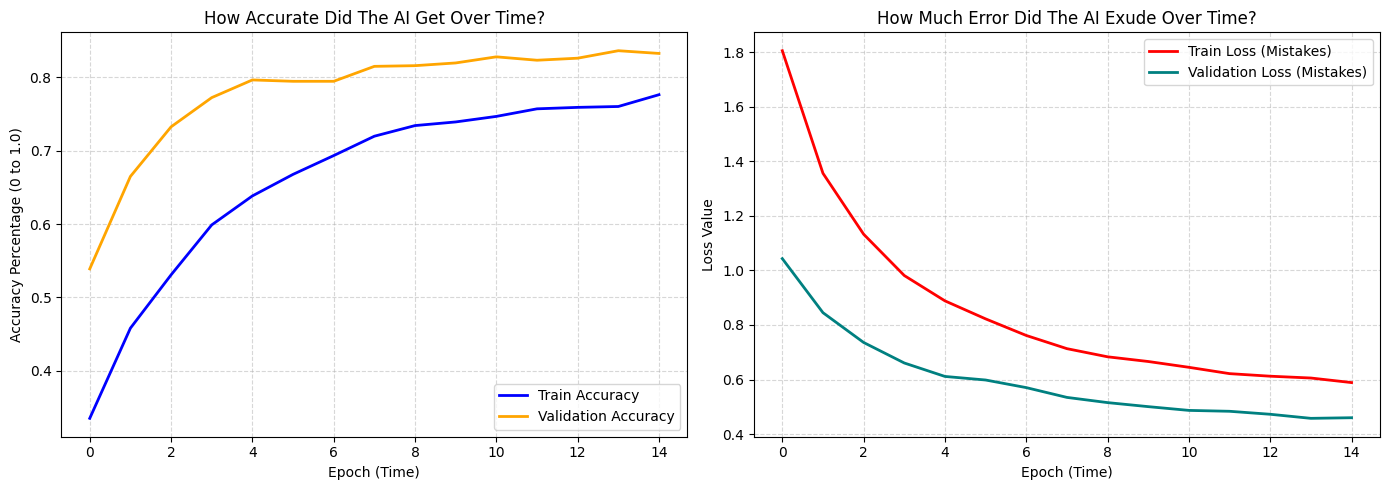

In [9]:
# Extract our learning data
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(14, 5))

# --- GRAPH 1: ACCURACY ---
# You want both these lines to go UP towards 1.0 (100%)
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy', linewidth=2, color='blue')
plt.plot(val_acc, label='Validation Accuracy', linewidth=2, color='orange')
plt.title('How Accurate Did The AI Get Over Time?')
plt.xlabel('Epoch (Time)')
plt.ylabel('Accuracy Percentage (0 to 1.0)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# --- GRAPH 2: LOSS (ERRORS/MISTAKES) ---
# You want both these lines to go DOWN towards 0 (Zero Mistakes)
plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss (Mistakes)', linewidth=2, color='red')
plt.plot(val_loss, label='Validation Loss (Mistakes)', linewidth=2, color='teal')
plt.title('How Much Error Did The AI Exude Over Time?')
plt.xlabel('Epoch (Time)')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 5. Evaluation & Final Testing 💯

The AI is trained! BUT, is it actually smart?
We will unleash the finalized model on the `Test Dataset` (The 15% of images kept totally hidden away in the `data_split/test/` folder).

It has **NEVER** seen these images before. We will grade the exam!

In [10]:
# Run the final evaluation against the unseen truth
print("Grading the Final Exam...\n")

test_loss, test_acc = model.evaluate(test_generator)

print(f"🎯 Final Test Accuracy: {test_acc * 100:.2f}%")
print(f"📉 Final Test Loss/Error: {test_loss:.4f}")

Grading the Final Exam...

68/68 ━━━━━━━━━━━━━━━━━━━━ 52s 755ms/step - accuracy: 0.8620 - loss: 0.4258
🎯 Final Test Accuracy: 86.20%
📉 Final Test Loss/Error: 0.4258


### 5B. The Confusion Matrix and Deep Metrics

A percentage isn't always enough. Did it perform worse on `Astrocitoma` than `Meningioma`? Let's predict all test images one-by-one, store the answers, and create an analytical grid (The Confusion Matrix).

68/68 ━━━━━━━━━━━━━━━━━━━━ 59s 846ms/step
----------- PREDICTION TEXT REPORT -----------
              precision    recall  f1-score   support

      glioma       0.90      0.85      0.88       270
  meningioma       0.78      0.72      0.75       270
     notumor       0.95      0.90      0.93       270
   pituitary       0.82      0.97      0.89       270

    accuracy                           0.86      1080
   macro avg       0.86      0.86      0.86      1080
weighted avg       0.86      0.86      0.86      1080



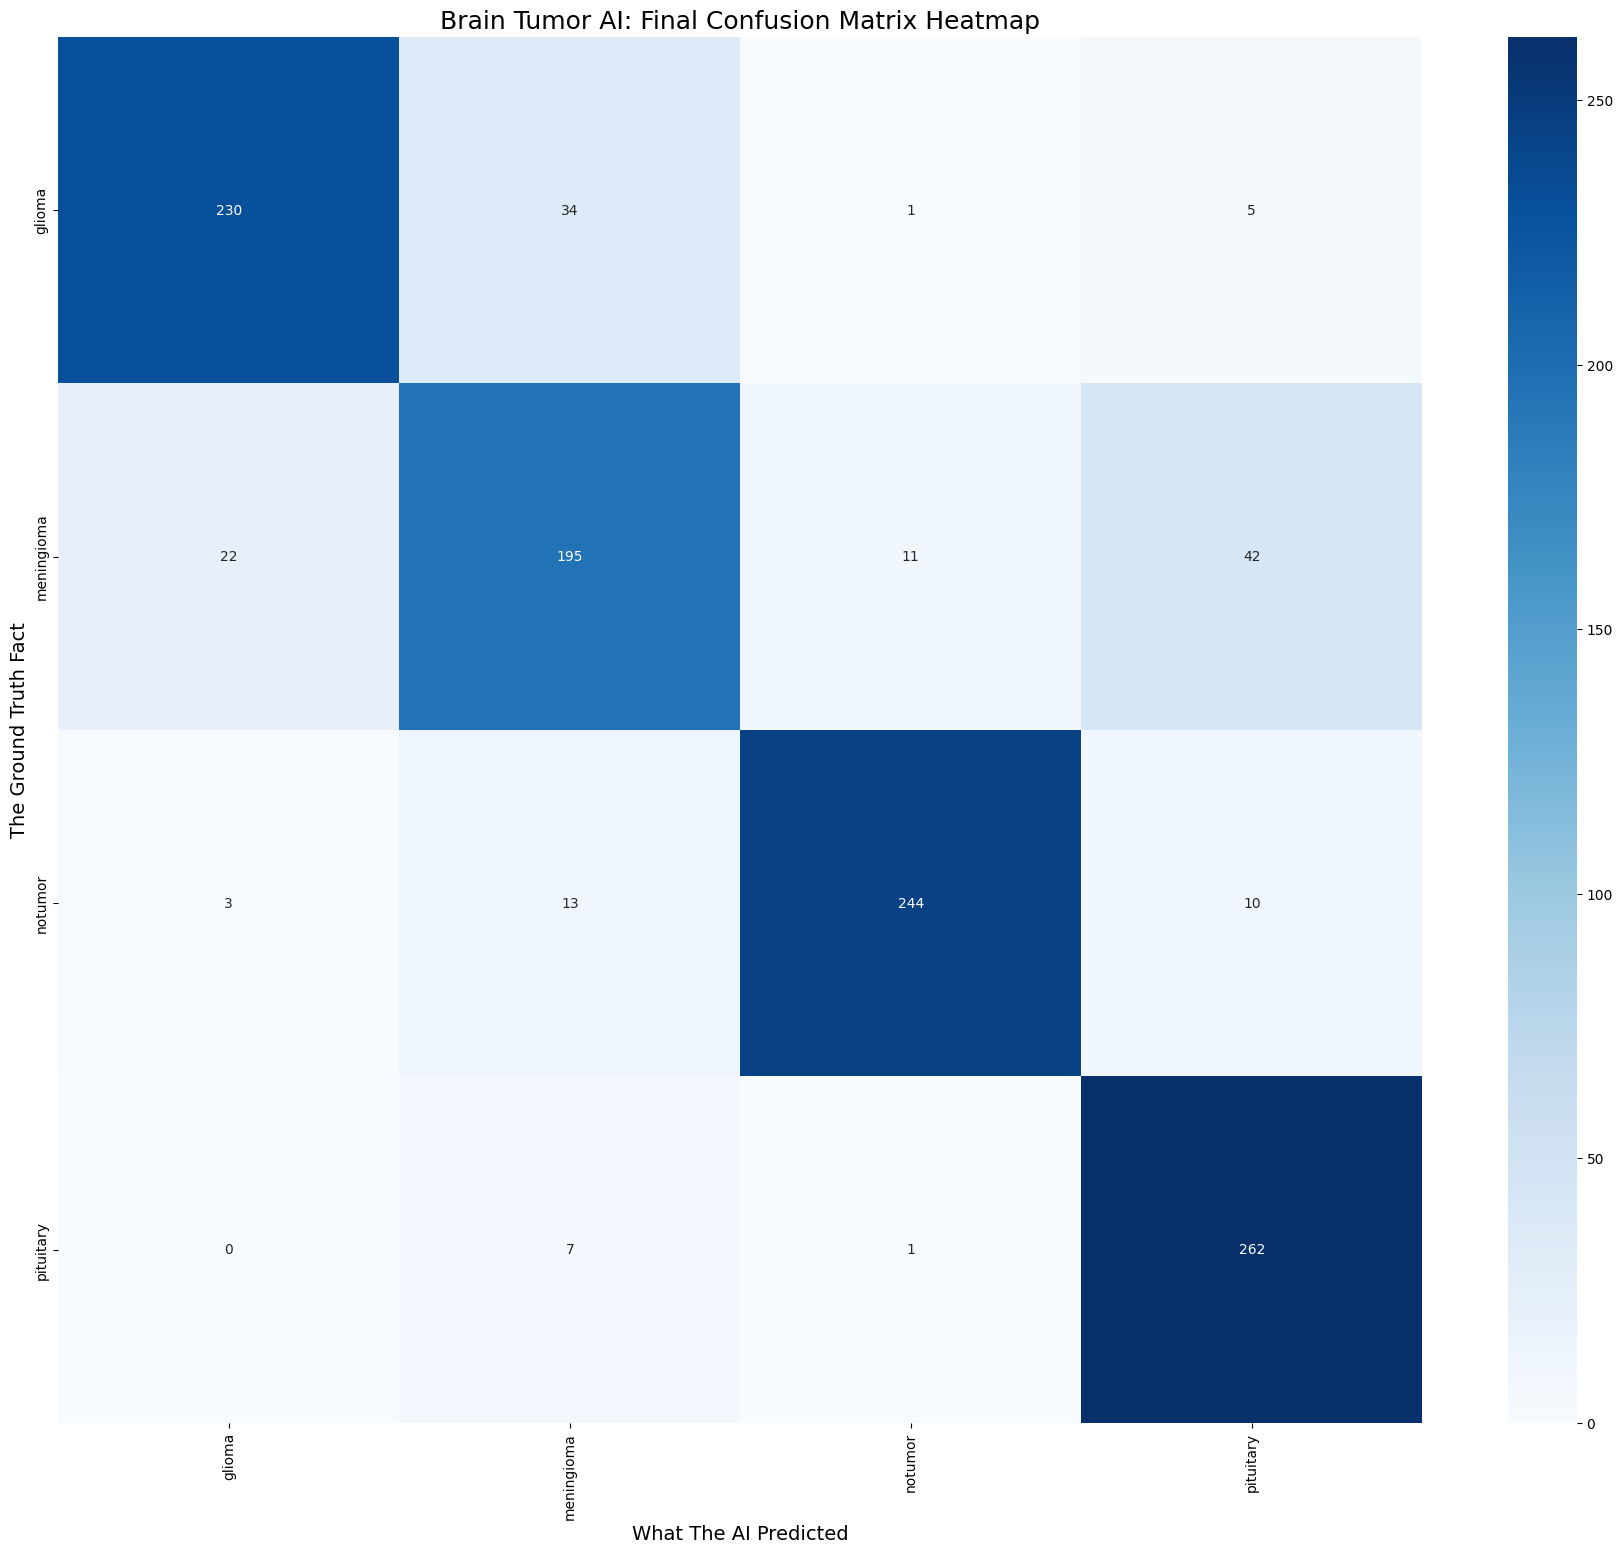

In [11]:
# 1. Reset generator so it predicts in perfect order
test_generator.reset()

# 2. Get the AI's 44-array Probability Guesses
predictions_prob = model.predict(test_generator)

# 3. Use 'argmax' to pick out which of the 44 probabilities was the Highest%
predicted_classes = np.argmax(predictions_prob, axis=1)

# 4. Extract the physical True/Fact Answers
true_classes = test_generator.classes

# --- PRINT TEXTUAL REPORT ---
print("----------- PREDICTION TEXT REPORT -----------")
print(classification_report(true_classes, predicted_classes, target_names=class_names))

# --- DRAW CONFUSION MATRIX GRAPH ---
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(22, 18))

# We use Seaborn (sns) to make the matrix look like a gorgeous Heatmap.
# The diagonal line should be dark blue (These are the Correct answers!)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

plt.title('Brain Tumor AI: Final Confusion Matrix Heatmap', fontsize=18)
plt.xlabel('What The AI Predicted', fontsize=14)
plt.ylabel('The Ground Truth Fact', fontsize=14)
plt.xticks(rotation=90)
plt.show()

### 5C. Visualizing Raw Output Predictions 📸

It's one thing to see numbers, but it's another to literally SEE the AI working!
Let's pull a random batch of 9 Brain MRI scans from the Test folder out of thin air, give them to the AI, and print its prediction on top of the physical image!

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


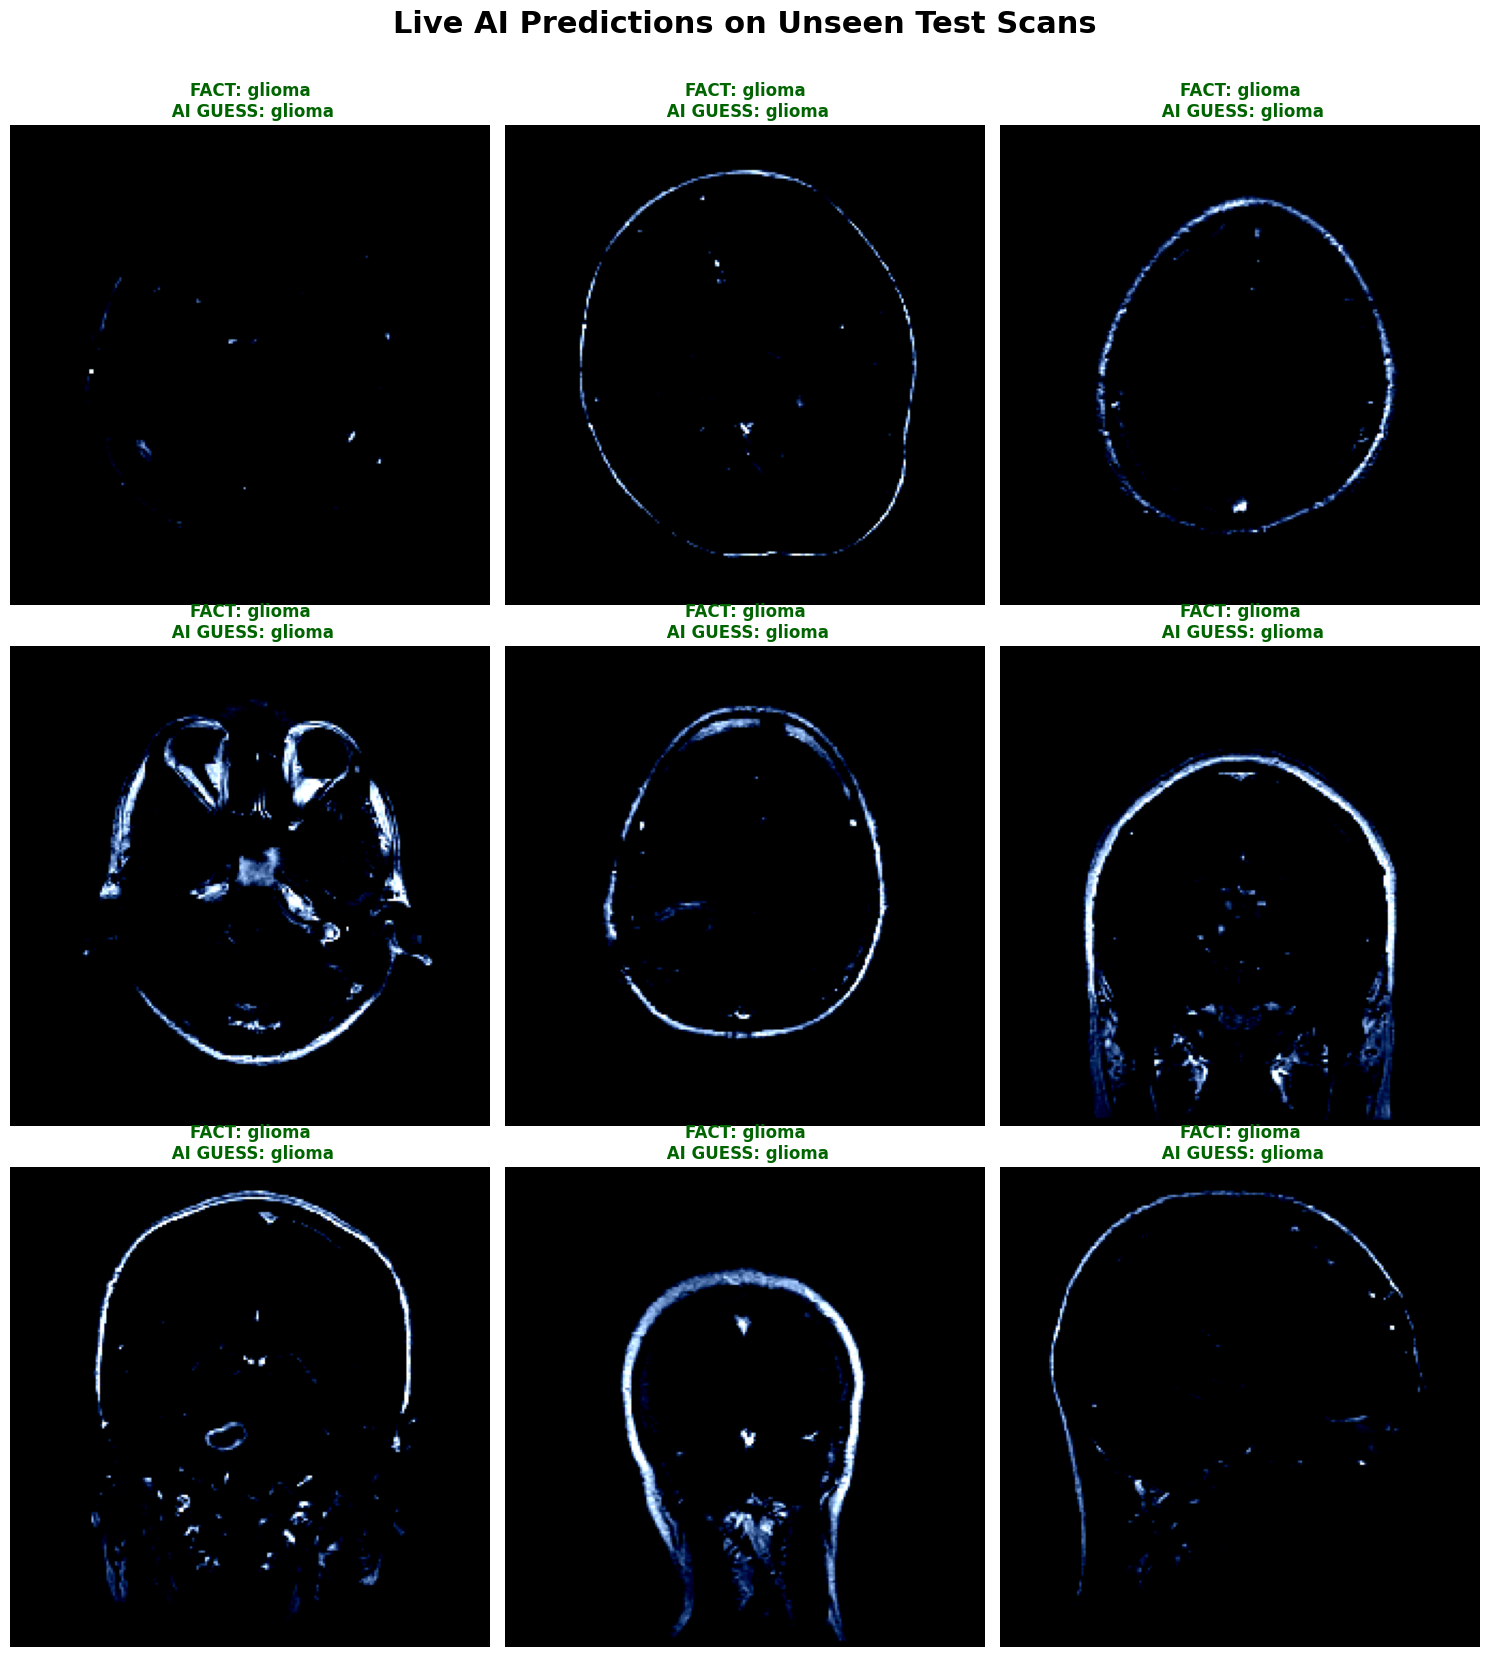

In [12]:
# We pull one batch (32 images) out from the unseen test generator
test_generator.reset()
images, onehot_labels = next(test_generator)

# Ask the model to guess on these 32 images
preds = model.predict(images)

# Convert the mathematically complex arrays back down to the 0-43 Index ID
pred_ids = np.argmax(preds, axis=1)
true_ids = np.argmax(onehot_labels, axis=1)

# Spawn a 3x3 Grid Graph
fig, axes = plt.subplots(3, 3, figsize=(15, 17))
axes = axes.ravel() # Flattens the array so we can easily loop through it

for i in range(9):
    if i < len(images):
        axes[i].imshow(images[i])
        
        # Look up the ID (e.g. "12") in the disease Dictionary to get the string ("Glioblastoma T1")
        true_name = class_names[true_ids[i]]
        pred_name = class_names[pred_ids[i]]

        # Text Color: Green if Correct, RED if the AI was wrong!
        text_color = "darkgreen" if true_ids[i] == pred_ids[i] else "darkred"
        
        axes[i].set_title(f"FACT: {true_name}\n AI GUESS: {pred_name}", color=text_color, fontweight="bold", fontsize=12)
        axes[i].axis('off') # Hide graph axes borders

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.suptitle('Live AI Predictions on Unseen Test Scans', fontsize=22, fontweight='bold')
plt.show()

In [13]:

y_pred_prob = model.predict(test_generator)

# Predicted class
y_pred_class = np.argmax(y_pred_prob, axis=1)

# Confidence = max probability for each prediction
confidence = np.max(y_pred_prob, axis=1)

# Count predictions with >= 95% confidence
high_conf_count = np.sum(confidence >= 0.95)
total = len(confidence)
print(f"Predictions with ≥95% confidence: {high_conf_count}/{total} ({high_conf_count/total*100:.2f}%)")

# Optional: show first 10 predictions
for i in range(10):
    print(f"Predicted: {y_pred_class[i]}, Confidence: {confidence[i]:.2f}")

68/68 ━━━━━━━━━━━━━━━━━━━━ 47s 686ms/step
Predictions with ≥95% confidence: 214/1080 (19.81%)
Predicted: 0, Confidence: 0.74
Predicted: 0, Confidence: 0.78
Predicted: 0, Confidence: 0.80
Predicted: 0, Confidence: 0.54
Predicted: 0, Confidence: 0.90
Predicted: 0, Confidence: 0.51
Predicted: 0, Confidence: 0.81
Predicted: 0, Confidence: 0.50
Predicted: 0, Confidence: 0.81
Predicted: 3, Confidence: 0.45


# Congratulations! 🎉

You have officially built, trained, debugged, and evaluated a deep learning convolutional neural network capable of accurately classifying 44 variants of brain tumors and diseases! 

*Next Steps: You might want to 'un-freeze' the base layers and train the model one final time on a very small learning rate to boost that final 2% accuracy. This is called 'Fine-Tuning'!*